# Final Project David Wu

## 3.1 Data

The dataset used for Stage 2 is a subset of a large multi-topic tweet corpus containing approximately 74,000 labeled tweets across 32 topics. We filtered to 24 video game-specific topics including Fortnite, Cyberpunk 2077, League of Legends, Call of Duty, and Dota 2, among others. Tweets labeled as Irrelevant were dropped, leaving three sentiment classes: Positive, Negative, and Neutral. The final dataset contains approximately 44,800 tweets. A stratified 85/15 train/test split was applied before any model training, yielding roughly 38,000 training samples and 6,700 held-out test samples. The class distribution is mildly imbalanced. Positive and Negative each account for approximately 33% of the data while Neutral comprises roughly 27%.


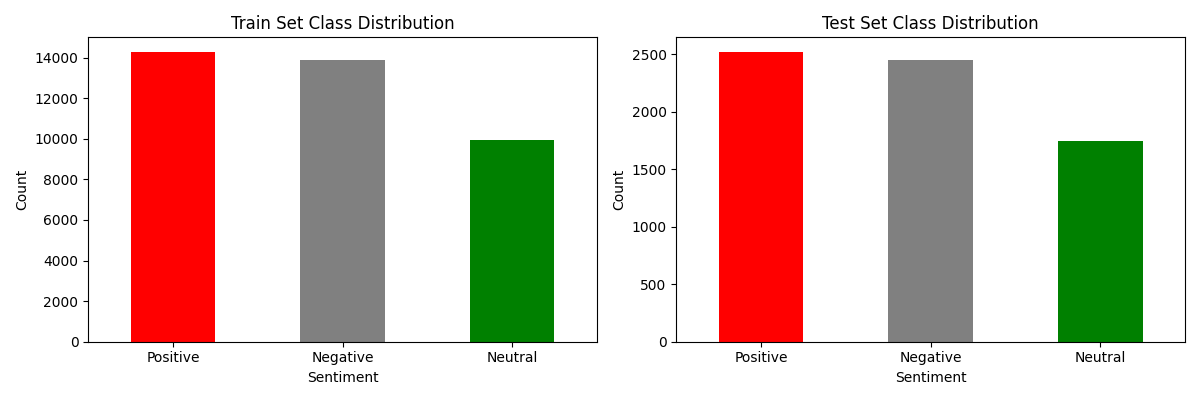

In [2]:
from IPython.display import Image
Image("3 -- results/1_class_distribution.png")

## 3.2 Model Architecture

We use DistilBERT (distilbert-base-uncased) as the base model, a distilled version of BERT that retains approximately 97% of BERT's performance at 40% fewer parameters. DistilBERT's default 2-class classification head was replaced with a 3-class head to accommodate Positive, Negative, and Neutral labels. To improve training efficiency, the embedding layer and first 4 of 6 transformer layers were frozen, leaving only the upper transformer layers and classification head trainable. This was approximately 22% of total parameters (14.7M of 66.9M).

## 3.3 Techniques

The model was fine-tuned using the HuggingFace Trainer API with the following hyperparameters:

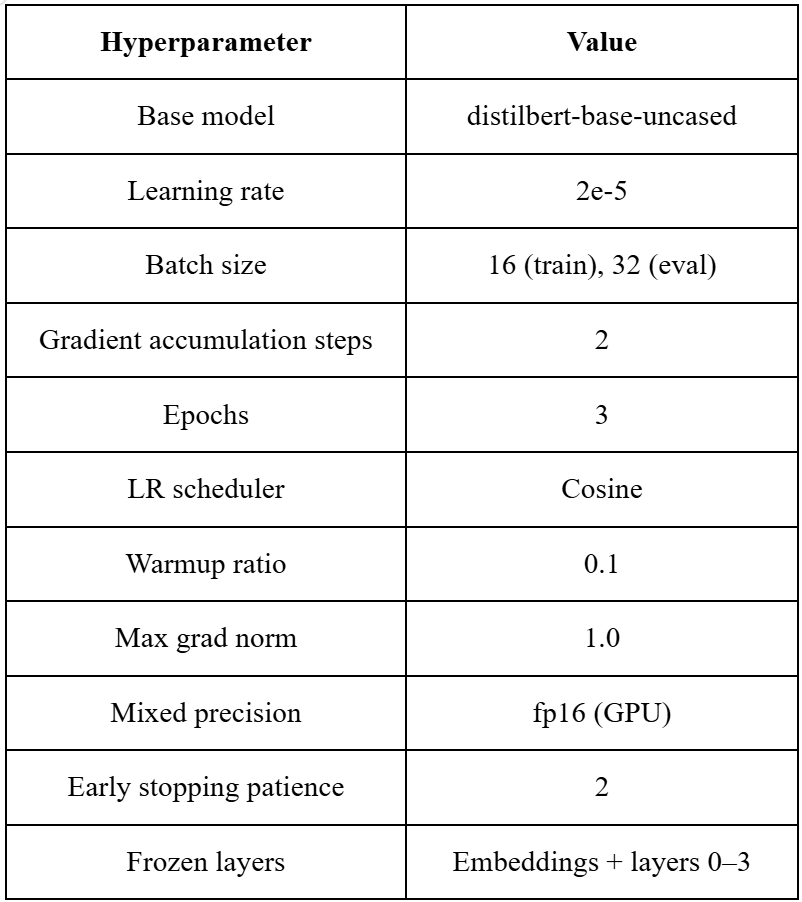

In [9]:
display(Image(filename="./3 -- results/training_parameters.png"))

## 3.4 Evaluation Metrics

The primary metrics are test set accuracy and macro F1 score. Macro F1 is emphasized over accuracy given the mild class imbalance, as it weights each class equally regardless of size. The baseline comparison is the raw untrained DistilBERT with a randomly initialized classification head, which produces confidence scores near 0.5 across all tweets — effectively a coin flip.

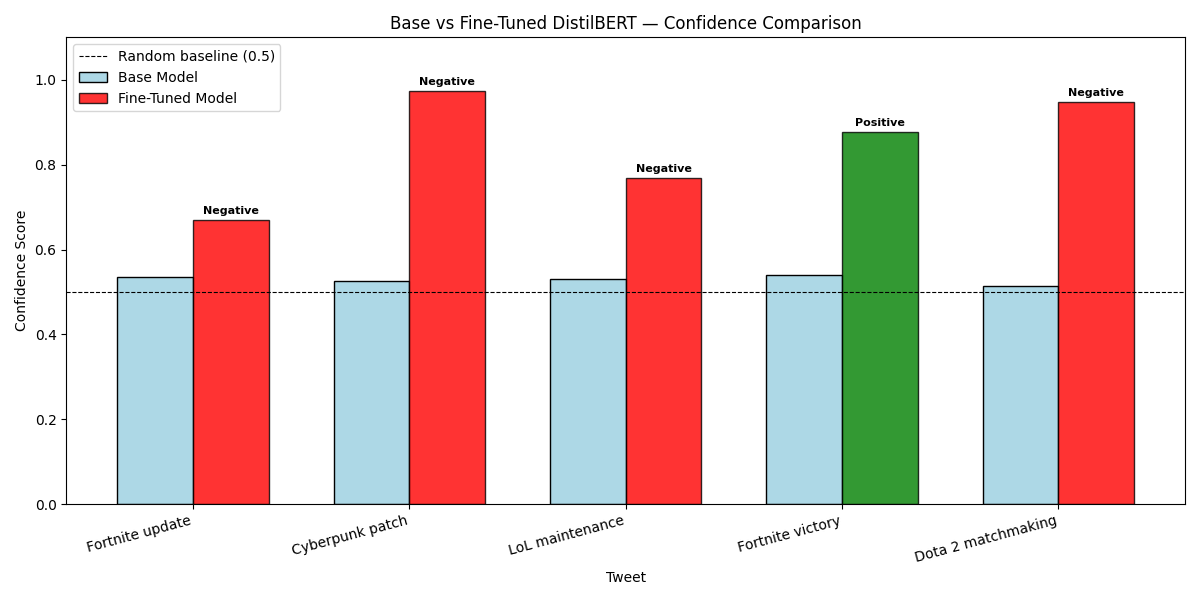

In [8]:
display(Image(filename="./3 -- results/5_baseline_comparison.png"))

## 4 Results

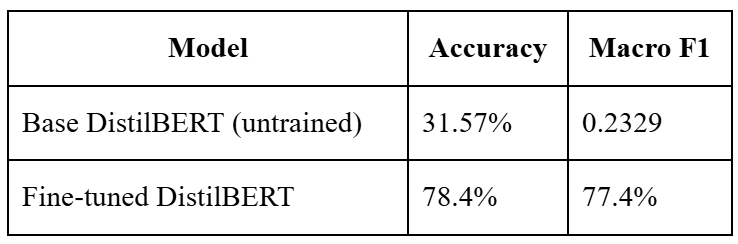

In [10]:
display(Image(filename="./3 -- results/model_accuracy.png"))

Training loss decreased steadily across all 3 epochs with no signs of overfitting, and the model never triggered early stopping.

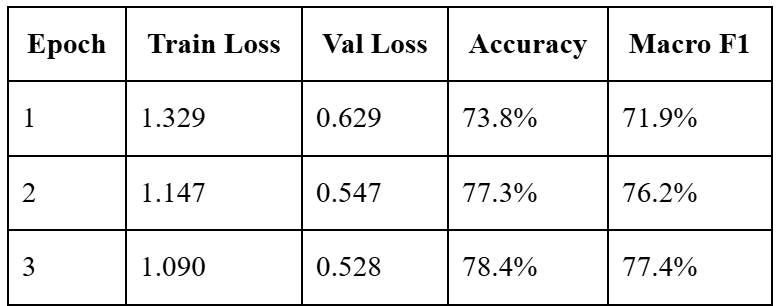

In [12]:
display(Image(filename="./3 -- results/training_loss.png"))

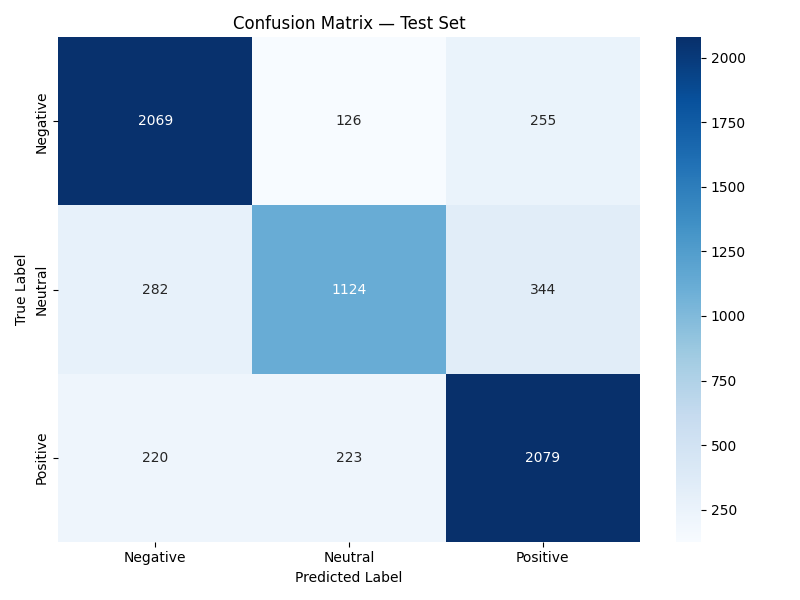

In [7]:
display(Image(filename="./3 -- results/2_confusion_matrix.png"))

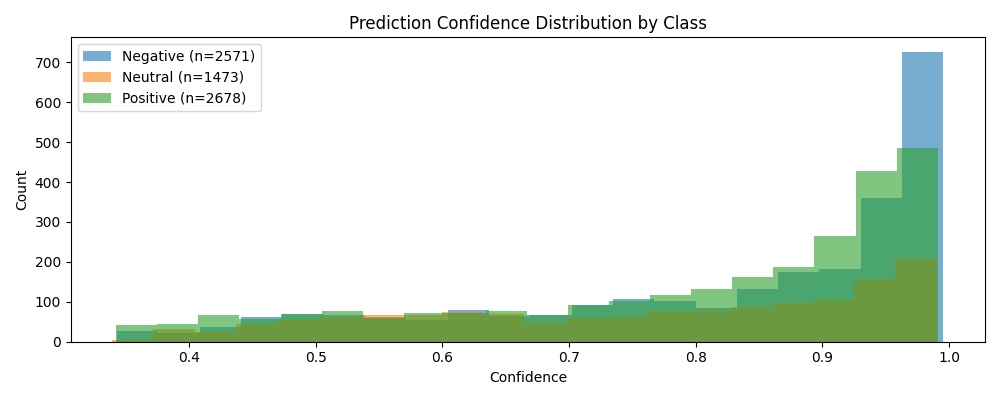

In [6]:
display(Image(filename="./3 -- results/3_confidence_distribution.png"))

**Qualitative Findings**

*Success case:* 
"This new Cyberpunk patch is absolute garbage, nothing works." → **Negative (0.97)**

*Failure case:* 
"Fortnite just dropped the best update ever, I can't stop playing!" → **Negative (0.67)**

The failure case illustrates a known edge case where enthusiastic gaming language is misread as negative. Notably the low confidence (0.67) indicates the model was uncertain, which is the correct behavior.

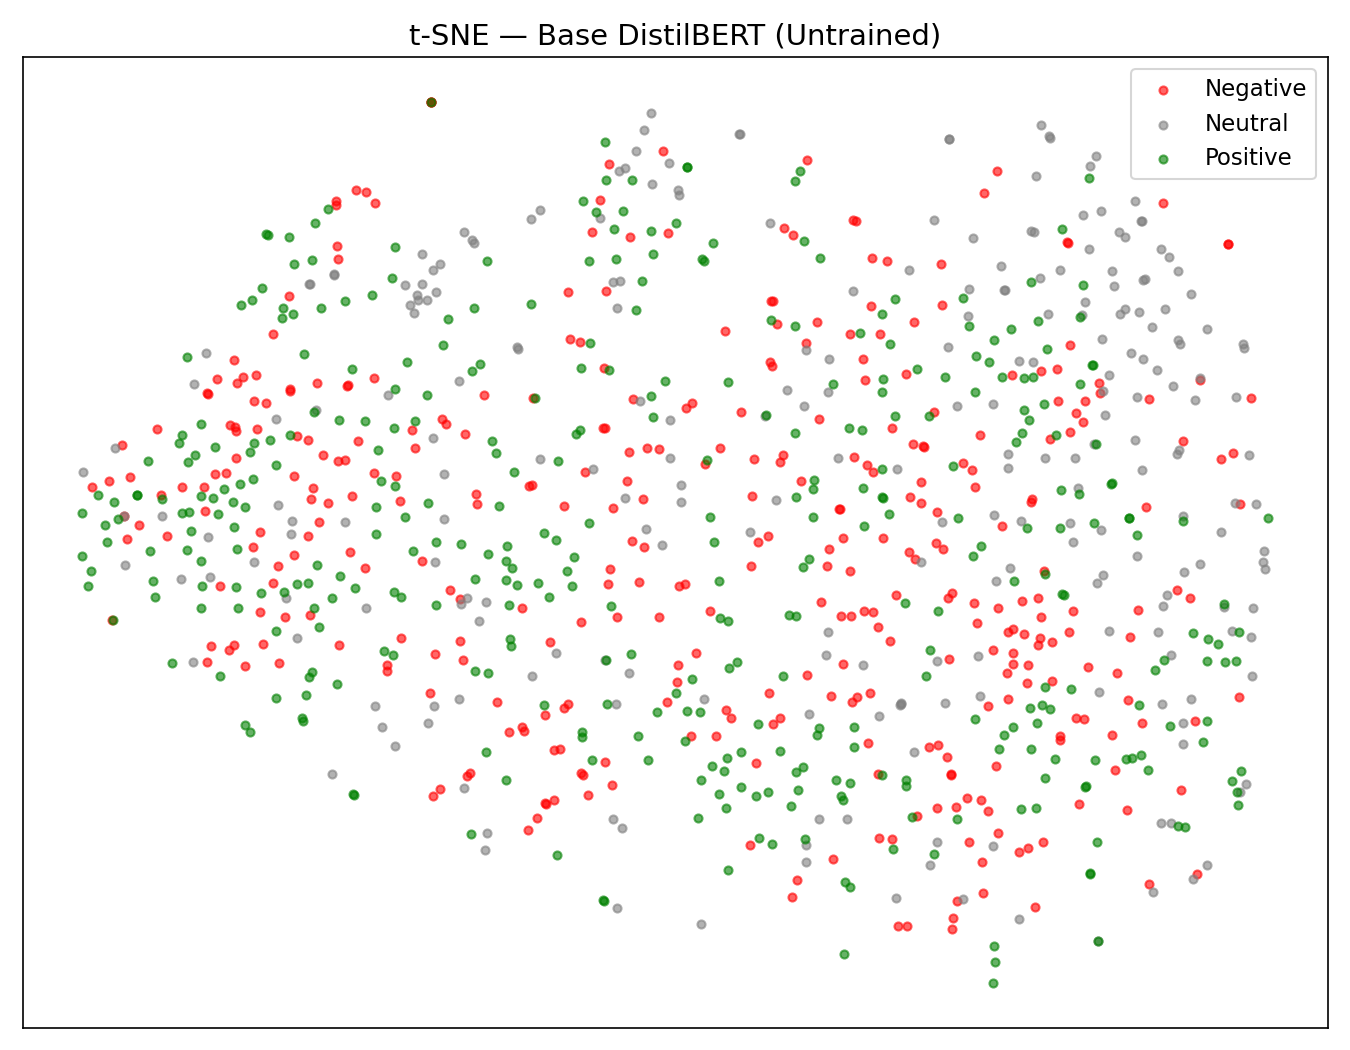

In [13]:
display(Image(filename="./3 -- results/7_tsne_base_model.png"))

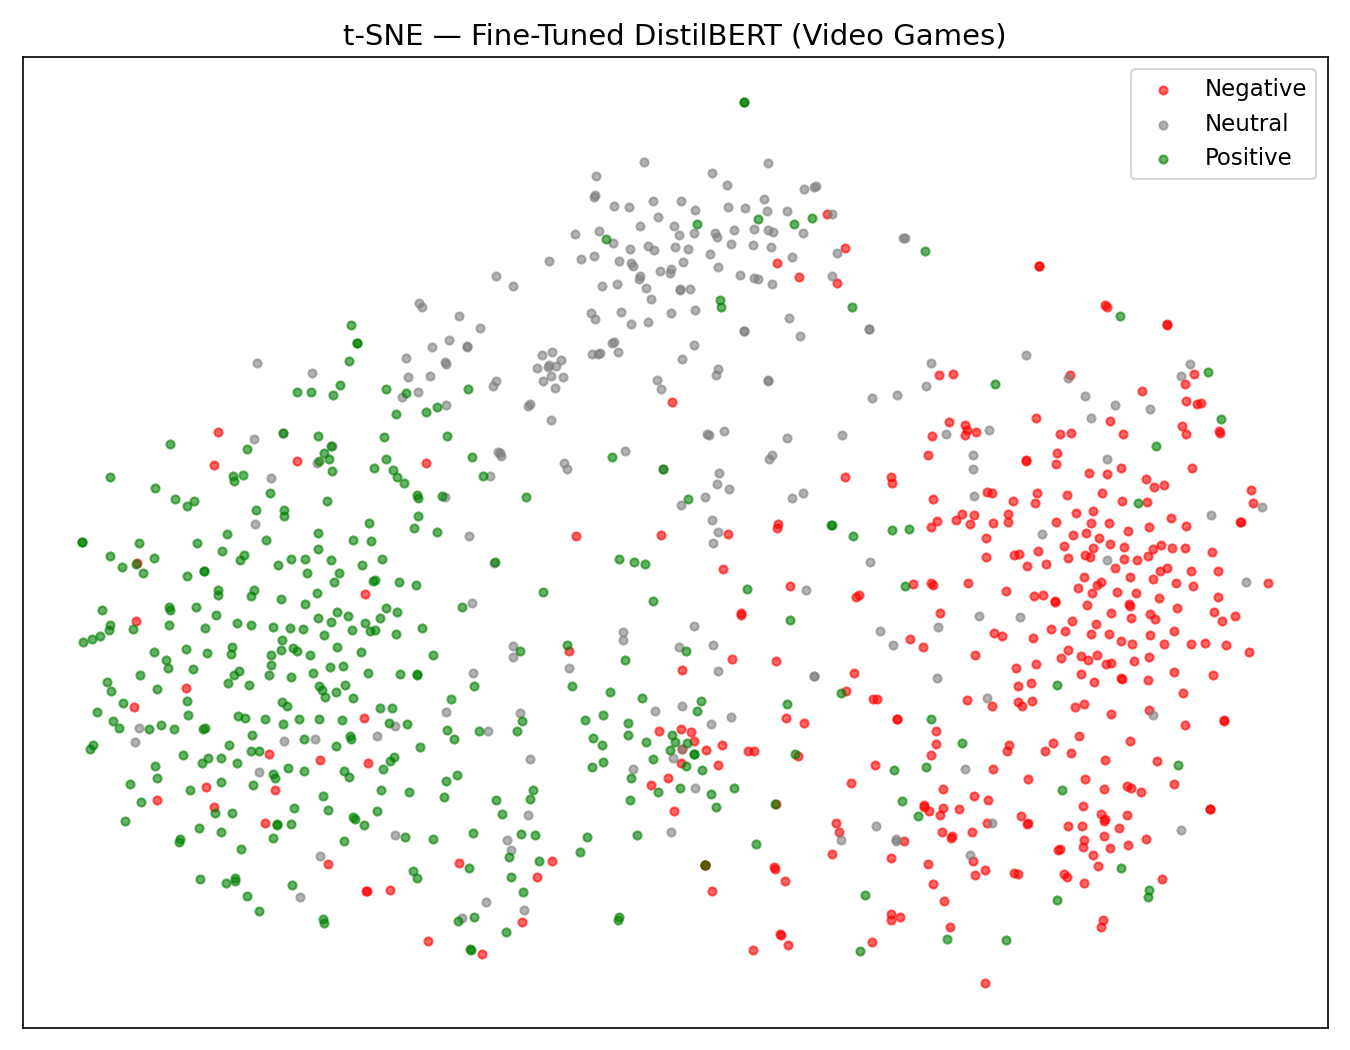

In [14]:
display(Image(filename="./3 -- results/7_tsne_finetuned_model.png"))

## 5 Discussion & Error Analysis

The confusion matrix reveals that Negative and Positive tweets are classified reliably, while Neutral is the weakest class, 344 neutral tweets were misclassified as Positive and 282 as Negative. This is expected: neutral tweets are factual or ambiguous in tone and share vocabulary with both sentiment extremes.

The primary limitation of the bot is the data. When pulling or selecting out the gaming tweets one of the things I noticed was the high volume of mislabeled tweets. We were uncertain about the quality of data but when reading through the sentiment classification of the most poorly-rated tweets we generally found that the classifier was right and the labeling was improper. Please refer to the csv of 4_worst_predictions in order to view tweets like, “@FortniteGame because they changed the map sincerely the game is just ruined like this and more with bots the problems and the story is shit but then I keep playing it what ever does really matter.” This was classified as negative which the language pretty clearly points towards while the labelling itself was neutral.

The secondary failure mode is domain-specific affective language. Gaming tweets frequently use aggressive or hyperbolic phrasing ("I will destroy you", "this game is killing me") that carries positive connotation in gaming culture but maps to negative sentiment in general text corpora. This is precisely the motivation for domain-specific fine-tuning, and highlights that even within the video games domain, sub-community language varies significantly across titles.

A tertiary limitation is the mild underrepresentation of Neutral tweets in training data, which likely contributes to the model's tendency to push ambiguous tweets toward Positive or Negative.

## 7 Individual Contributions --- David Wu

* Filtered and preprocessed the raw tweet dataset to the video games domain
* Performed stratified train/test split and ensured test set isolation prior to training
* Fine-tuned DistilBERT for 3-class sentiment classification using HuggingFace Trainer API
* Designed and ran diagnostic evaluation pipeline (class distribution, confusion matrix, confidence analysis, worst-case prediction analysis)
* Conducted baseline vs. fine-tuned comparison analysis
* Authored Sections 3.1, 3.2, 3.3, 3.4, Stage 2 Results, and Stage 2 Discussion

**Sources used/ Bibliography:**

jp797498e. Twitter Entity Sentiment Analysis. Kaggle dataset. Accessed March 16, 2026. https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis. 